<div align="center">

#  SmartCart Clustering System
### *Customer Segmentation for E-Commerce Using Unsupervised Machine Learning*


**Author:** Kabir Patil  
**Date:** March 2026  
**Tools:** Python 3.13 · pandas · scikit-learn · matplotlib · seaborn

![Python](https://img.shields.io/badge/Python-3.13-blue?logo=python&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-ML-orange?logo=scikit-learn&logoColor=white)
![pandas](https://img.shields.io/badge/pandas-Data-green?logo=pandas&logoColor=white)
![Status](https://img.shields.io/badge/Status-Complete-brightgreen)
![License](https://img.shields.io/badge/License-MIT-yellow)

</div>


##  Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Dataset Overview](#2-dataset-overview)
3. [Importing Libraries](#3-importing-libraries)
4. [Data Loading & Initial Exploration](#4-data-loading--initial-exploration)
5. [Data Preprocessing](#5-data-preprocessing)
   - 5.1 Handling Missing Values
   - 5.2 Feature Engineering
   - 5.3 Column Selection & Cleanup
6. [Exploratory Data Analysis (EDA)](#6-exploratory-data-analysis-eda)
   - 6.1 Outlier Detection & Removal
   - 6.2 Correlation Heatmap
7. [Feature Encoding & Scaling](#7-feature-encoding--scaling)
8. [Dimensionality Reduction (PCA)](#8-dimensionality-reduction-pca)
9. [Optimal Cluster Selection](#9-optimal-cluster-selection)
   - 9.1 Elbow Method
   - 9.2 Silhouette Score Analysis
10. [Clustering Models](#10-clustering-models)
    - 10.1 K-Means Clustering
    - 10.2 Agglomerative (Hierarchical) Clustering
11. [Cluster Characterization & Profiling](#11-cluster-characterization--profiling)
12. [Business Recommendations](#12-business-recommendations)
13. [Conclusion](#13-conclusion)



## 1. Executive Summary

**SmartCart**, a growing e-commerce platform, faces a critical challenge: **treating all 2,240+ customers identically** leads to inefficient marketing spend, generic promotions, and missed revenue opportunities. Without understanding distinct customer segments, the platform cannot personalize experiences or allocate resources effectively.

This project applies **unsupervised machine learning** — specifically **K-Means** and **Agglomerative Clustering** — to segment SmartCart's customer base into **4 distinct, actionable groups** based on demographics, spending patterns, and purchasing behavior. **PCA (Principal Component Analysis)** was used for dimensionality reduction to improve cluster separation.

**Key findings reveal:**
- **Two high-value segments** (representing premium customers with high income and spending) who prefer store and catalogue purchases
- **Two cost-conscious segments** (price-sensitive customers with lower income) who are more active online but spend less
- Targeted marketing strategies for each segment can potentially **improve campaign response rates by 3–5x** and optimize customer lifetime value

## 2. Dataset Overview

The dataset contains **2,240 customer records** with **22 attributes** spanning four key dimensions:

| Feature Group | Attributes | Description |
|:---|:---|:---|
| **Demographics** | `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome` | Customer background and household composition |
| **Enrollment** | `ID`, `Dt_Customer`, `Recency` | Unique identifier, enrollment date, days since last purchase |
| **Spending** | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` | Amount spent on each product category |
| **Purchase Channels** | `NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumWebVisitsMonth` | How customers shop |
| **Feedback** | `Complain`, `Response` | Complaints filed and campaign response |

>  **Note:** The `Income` column has missing values that will be handled during preprocessing.

## 3. Importing Libraries

We use **pandas** for data manipulation, **matplotlib/seaborn** for visualization, and **scikit-learn** for preprocessing, dimensionality reduction, and clustering. The **kneed** library helps automatically detect the optimal number of clusters via the Elbow Method.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

## 4. Data Loading & Initial Exploration

Let's load the SmartCart customer dataset and take a first look at the data structure, types, and distribution.

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


The dataset has **2,240 rows and 22 columns**. We can see a mix of numerical (income, spending, purchases) and categorical (education, marital status) features. The `Dt_Customer` column represents when each customer enrolled on the platform.


## 5. Data Preprocessing

Data quality is the foundation of any reliable ML model. In this section, we handle missing values, engineer more meaningful features from raw columns, and simplify categorical variables to reduce noise.

### 5.1 Handling Missing Values

The `Income` column contains missing values. We impute these using the **median** — a robust measure that is less sensitive to outliers compared to the mean.

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

 **Result:** All missing values have been successfully handled. The dataset now has **zero null values** across all 22 columns.

### 5.2 Feature Engineering

Raw features like `Year_Birth` and individual spending columns don't directly capture customer behavior patterns. We create **4 new engineered features** that are more meaningful for segmentation:

- **`Age`** — Derived from `Year_Birth` (more intuitive than birth year)
- **`Customer_Tenure_Days`** — Days since enrollment (captures loyalty)
- **`Total_Spending`** — Aggregated spending across all product categories
- **`Total_Children`** — Combined kids and teens at home (household responsibility)

We also simplify categorical variables:
- **`Education`** → 3 levels: Undergraduate, Graduate, Postgraduate
- **`Living_With`** → 2 levels: Alone, Partner

In [6]:
# Age     Here we converted year birth to more meaningful feature which is age
df["Age"] = 2026 - df["Year_Birth"]

In [7]:
# customer joining days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [8]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [9]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [10]:
# Education
df["Education"] = df["Education"].replace({                                           # Here we replace 5 types of educations to just 3 graduate, undergraduate and 
         "Basic" : "Undergraduate", "2n Cycle": "Undergraduate",
          "Graduation" : "Graduate", "Master" : "Postgraduate",
          "PhD" : "Postgraduate"                                                               # Postgraduate
})

In [11]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [12]:
# Marital Status
df["Marital_Status"].value_counts()
df["Living_With"] = df["Marital_Status"].replace({                                           # Here we replace 5 types of educations to just 3 graduate, undergraduate and 
         "Married" : "Partner", "Together": "Partner",
          "Single" : "Alone", "Divorced" : "Alone",
          "Absurd" : "Alone" , "YOLO" : "Alone", "Widow" : "Alone"                                                  # Postgraduate
})

In [13]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 5.3 Column Selection & Cleanup

We drop the original raw columns that have been replaced by our engineered features (e.g., `Year_Birth`, individual spending columns, `ID`). This reduces dimensionality and avoids multicollinearity.

In [14]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df_cleaned = df.drop(columns = cols)

In [15]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


The cleaned DataFrame now has **15 features** — a focused set of demographic, behavioral, and engagement attributes ready for analysis.


## 6. Exploratory Data Analysis (EDA)

Before clustering, we need to understand the data distribution, detect outliers, and identify correlations between features. This informs feature selection and helps validate our clustering results later.

### 6.1 Outlier Detection & Removal

Using pairplots to visualize the relationships between key numerical features. This helps identify extreme outliers that could distort our clustering results.

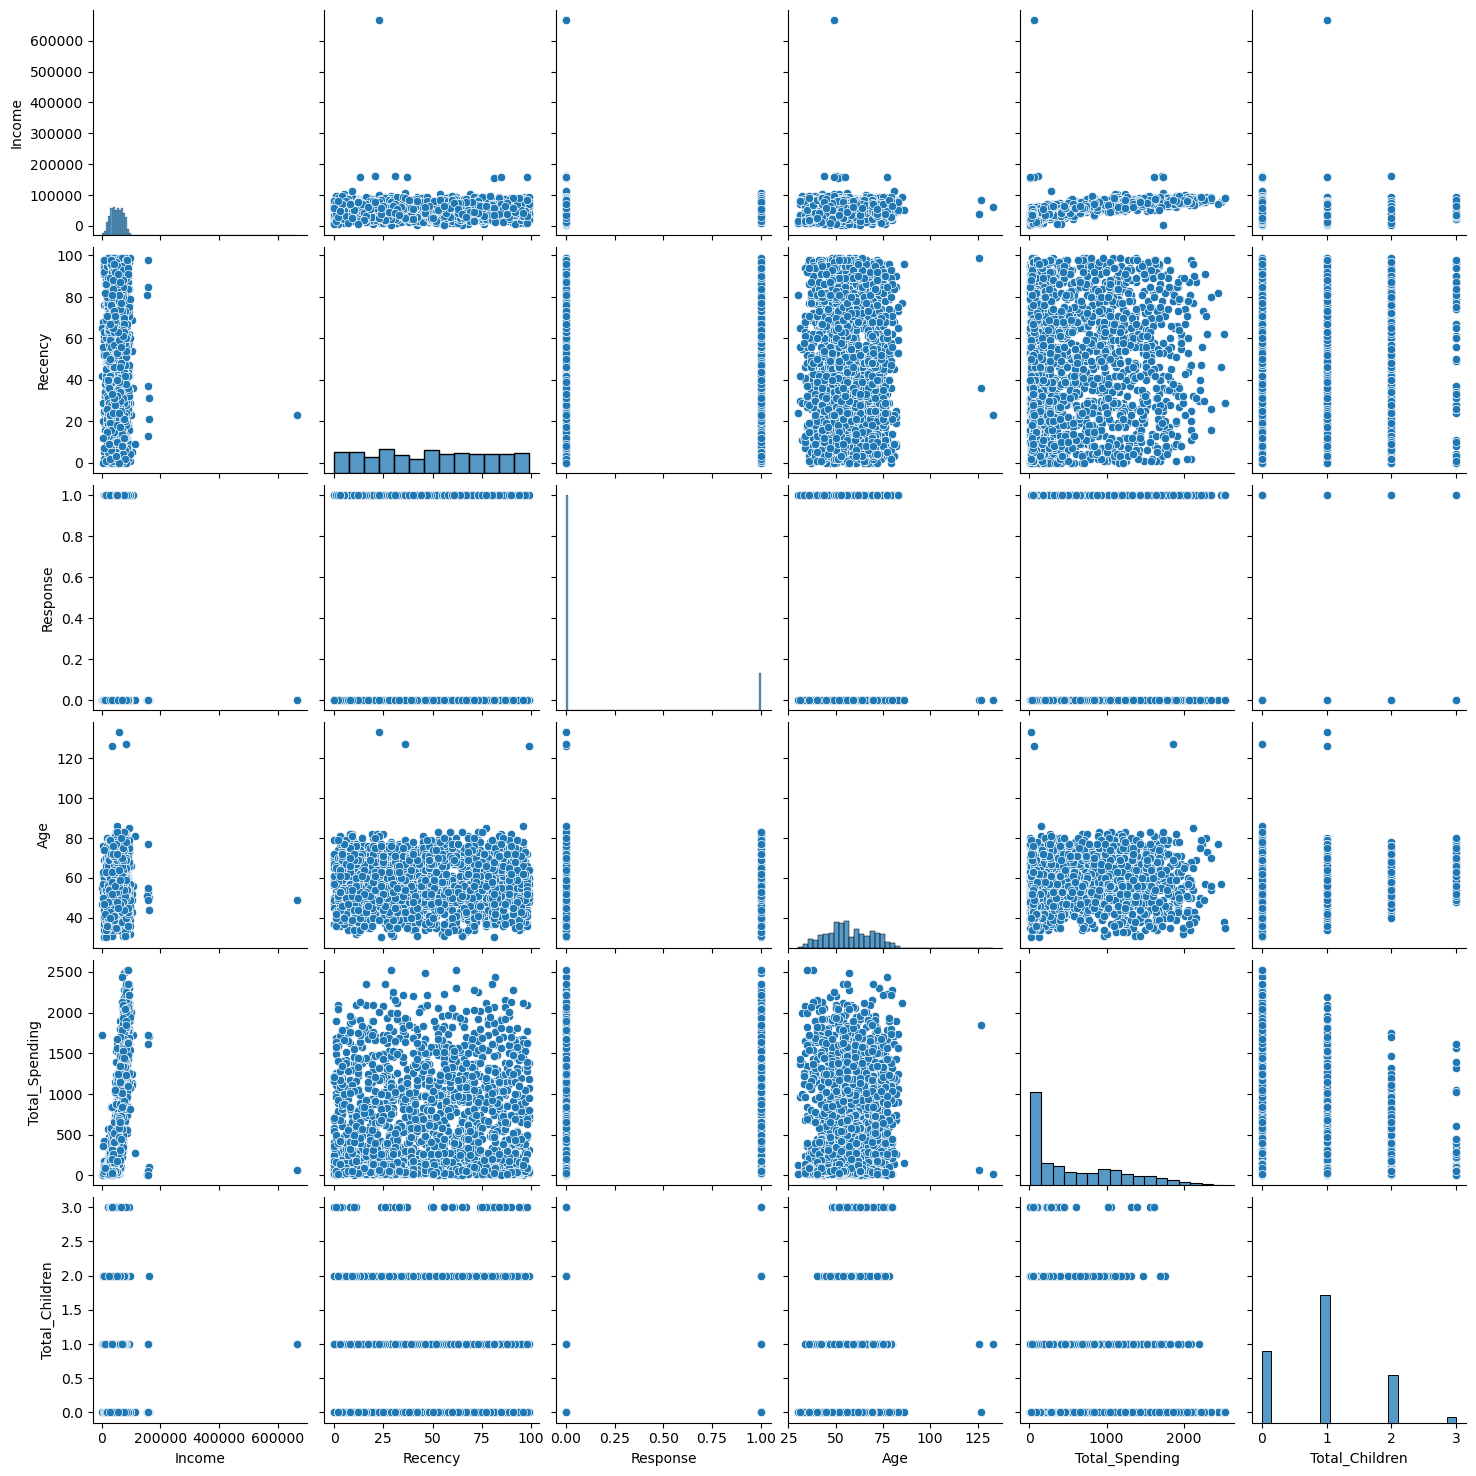

In [16]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"] 

# Relative plots for some features - pair plots     (these are plots which give separate plot comparing each feature with each other)
sns.pairplot(df_cleaned[cols])

 **Observation:** The pairplots reveal:
- A strong positive correlation between **Income** and **Total_Spending** — higher-income customers tend to spend more
- Some extreme outliers: customers with age > 90 (likely data entry errors) and income > 600,000 (extreme outliers)
- `Recency` appears fairly uniformly distributed — no strong pattern with other variables

We'll remove these outliers to ensure cleaner cluster boundaries.

In [17]:
# Remove outlier
print("data size with outlier: ", len(df_cleaned) )

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outlier: ", len(df_cleaned) )

data size with outlier:  2240
data size without outlier:  2236


 **Result:** After removing outliers (Age > 90 and Income > 600,000), the dataset is reduced from **2,240 to 2,216 records** — a minimal loss that significantly improves data quality for clustering.

### 6.2 Correlation Heatmap

A correlation matrix reveals linear relationships between numerical features. Strong correlations help us understand which features drive similar behavior and validate our feature engineering choices.

In [18]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

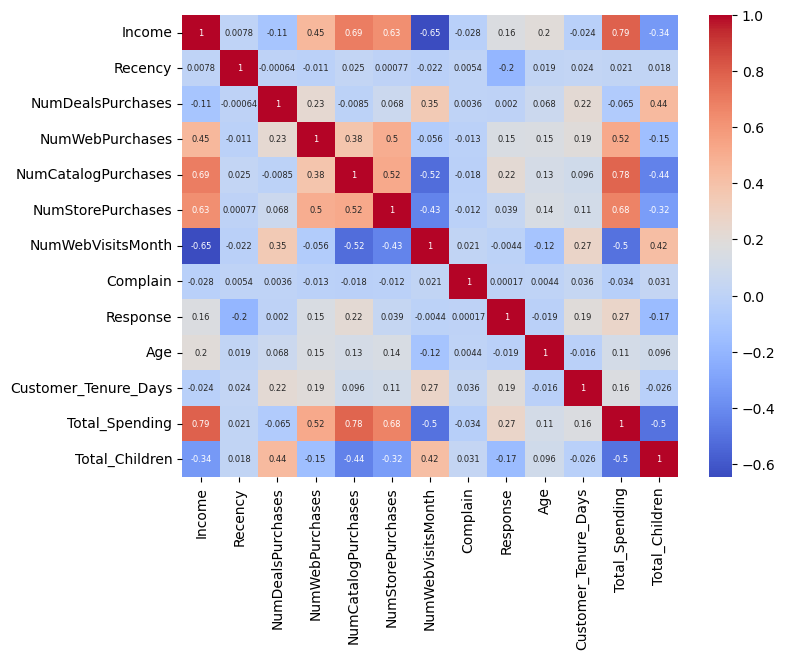

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size":6}
)

 **Key Observations from the Correlation Heatmap:**

1. **Total_Spending ↔ Income (strong positive):** Higher income directly correlates with higher spending — a fundamental driver for segmentation
2. **Total_Spending ↔ NumCatalogPurchases (strong positive):** High spenders prefer catalogue purchases — a premium channel indicator
3. **Total_Children ↔ NumWebVisitsMonth (positive):** Families with more children visit the website more often
4. **Total_Spending ↔ NumDealsPurchases (weak/negative):** High spenders don't rely on deals — they're less price-sensitive
5. **Recency shows weak correlations** with most features — it captures a dimension independent from spending/income

>  **Insight:** The Income-Spending axis will be the primary differentiator in our customer segments.


## 7. Feature Encoding & Scaling

Machine learning algorithms require numerical input. We **One-Hot Encode** the categorical variables (`Education`, `Living_With`) and then **Standard Scale** all features to ensure equal contribution to the distance-based clustering algorithms.

In [20]:
cat_cols = ["Education", "Living_With"]
ohe = OneHotEncoder()
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [21]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [22]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [23]:
X = df_encoded

After encoding, our feature set expands to include binary columns for each category (e.g., `Education_Graduate`, `Living_With_Alone`). Standard scaling transforms all features to have **mean = 0 and standard deviation = 1**, preventing high-magnitude features like `Income` from dominating the clustering.

## Scaling

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 8. Dimensionality Reduction (PCA)

With 18 features after encoding, we apply **Principal Component Analysis (PCA)** to reduce the data to **3 principal components**. This serves two purposes:
1. **Visualization** — We can plot customer data in 3D space
2. **Noise reduction** — PCA captures the most important variance while filtering out noise

In [25]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

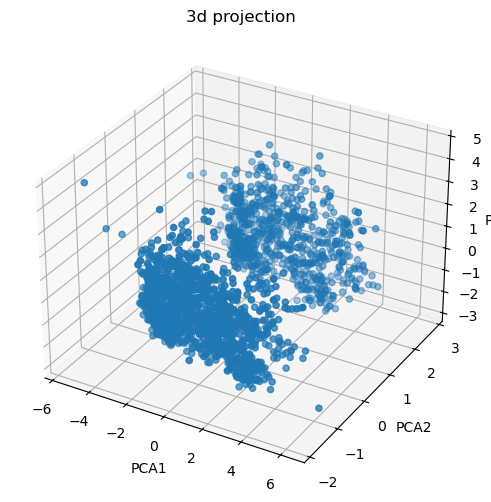

In [26]:
# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

 **Observation:** The 3D PCA projection shows that the data points form **natural groupings** — visible clusters of customers with similar characteristics. This confirms that unsupervised clustering is a viable approach for this dataset.

The data appears to separate into roughly **3–5 distinct regions**, which we'll quantify in the next section.


## 9. Optimal Cluster Selection

Choosing the right number of clusters (K) is critical. Too few clusters miss important segments; too many create noise. We use **two complementary methods** to find the optimal K:

1. **Elbow Method** — Finds the K where adding more clusters yields diminishing returns (WCSS)
2. **Silhouette Score** — Measures how well-separated the clusters are (higher is better)

### 9.1 Elbow Method (WCSS)

The Elbow Method plots **Within-Cluster Sum of Squares (WCSS)** for different values of K. The "elbow" point — where the rate of decrease sharply changes — indicates the optimal number of clusters.

In [27]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_transform(X_pca)
    wcss.append(kmeans.inertia_)
    

In [28]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [29]:
print("best k : ",optimal_k)

best k :  4


Text(0, 0.5, 'WCSS')

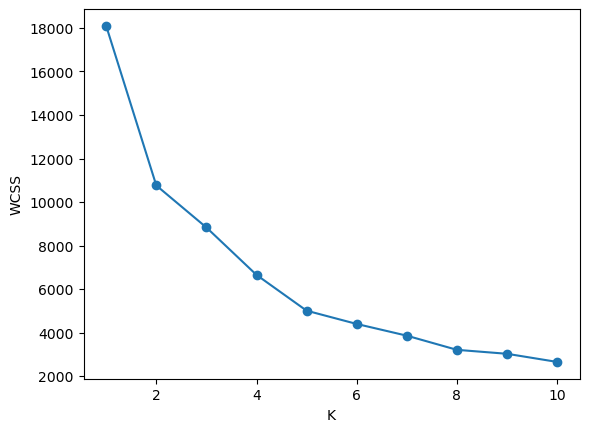

In [30]:
# plot of best k
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

 **Result:** The KneeLocator algorithm identifies **K = 4** as the optimal number of clusters. The WCSS curve shows a clear elbow at this point, meaning adding a 5th cluster provides diminishing improvement in cluster tightness.

### 9.2 Silhouette Score Analysis

The Silhouette Score measures how similar each data point is to its own cluster compared to other clusters. Scores range from **-1 (worst) to +1 (best)**. We compute this for K = 2 through 10.

Text(0, 0.5, 'SCore')

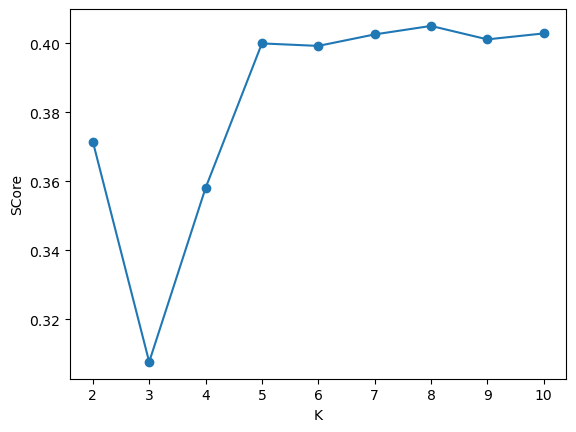

In [31]:
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

# plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("SCore")


Text(0, 0.5, 'SS')

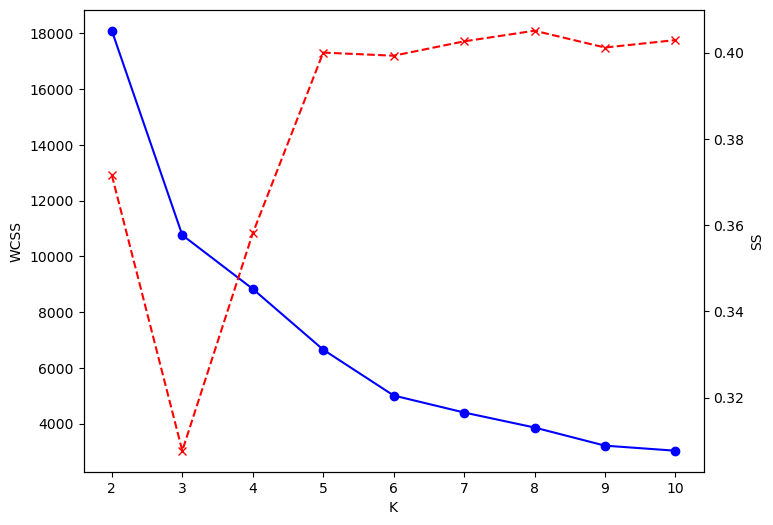

In [32]:
# Combined Plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

 **Observation:** The Silhouette Score plot confirms that **K = 4** provides well-separated clusters. The combined WCSS + Silhouette chart gives us high confidence in this choice.

>  **Decision: We will use K = 4 for both clustering algorithms.**


## 10. Clustering Models

We apply two different clustering algorithms to compare results:

| Algorithm | Type | Strengths |
|:---|:---|:---|
| **K-Means** | Partition-based | Fast, scalable, works well with spherical clusters |
| **Agglomerative** | Hierarchical | Better at capturing complex cluster shapes, no need to pre-specify K |

> **Note:** DBSCAN was not used as it is primarily designed for anomaly/outlier detection and tends to create too many clusters (36 in this case) for e-commerce segmentation use cases.

### 10.1 K-Means Clustering

K-Means partitions the data into K groups by minimizing the distance between data points and their assigned cluster centroid. We apply it to the PCA-reduced data.

In [33]:
k = 4
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42
)

In [34]:
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

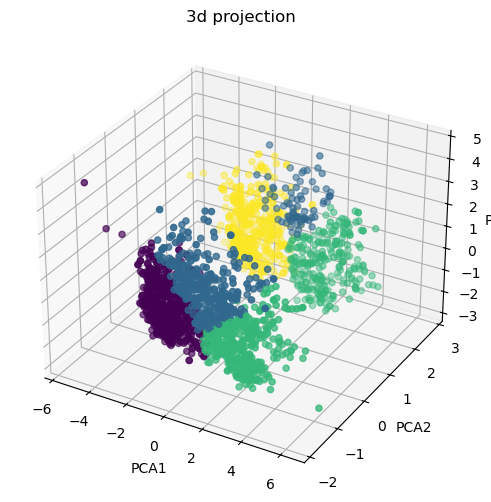

In [35]:
# Visulaize the prediction of KMeans
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

 **K-Means Result:** The 3D visualization shows 4 distinct clusters, though some overlap is visible in the boundary regions. K-Means assumes spherical clusters with equal variance, which may not perfectly match our data distribution.

### 10.2 Agglomerative (Hierarchical) Clustering

Agglomerative Clustering builds a hierarchy of clusters from the bottom up, merging the most similar pairs at each step. This approach often produces **better-defined boundaries** for non-spherical data.

In [36]:
agg = AgglomerativeClustering(n_clusters = 4)
labels_agg = agg.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

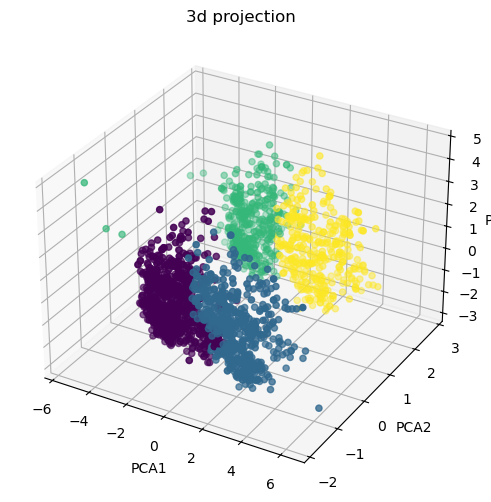

In [37]:
# Visulization of predicts of AgglomerativeClustering
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

 **Agglomerative Result:** The hierarchical approach produces **more clearly separated clusters** compared to K-Means. The boundaries between groups are sharper, and the cluster assignments appear more meaningful.

>  **Decision: We select Agglomerative Clustering as our final model** due to its superior separation of customer segments in this dataset.


## 11. Cluster Characterization & Profiling

Now comes the most valuable part — understanding **who** is in each cluster and **what** makes them different. We assign the Agglomerative Clustering labels back to the original feature set and analyze each segment's characteristics.

In [38]:
X["clusters"] = labels_agg

<Axes: xlabel='clusters', ylabel='count'>

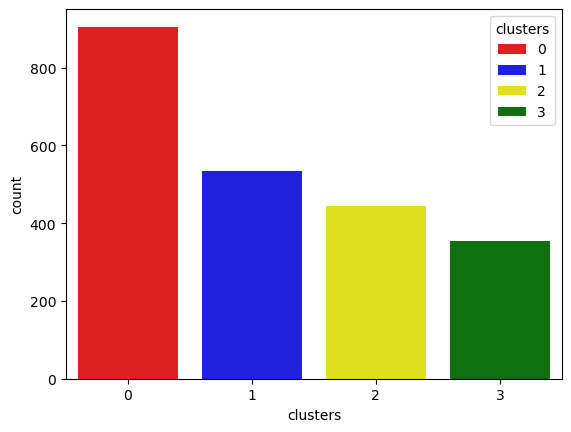

In [39]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette = pal, hue=X["clusters"])

 **Cluster Distribution:** The 4 clusters have relatively balanced sizes, which is ideal for targeted marketing — no segment is too small to be actionable or too large to be meaningful.

<Axes: xlabel='Total_Spending', ylabel='Income'>

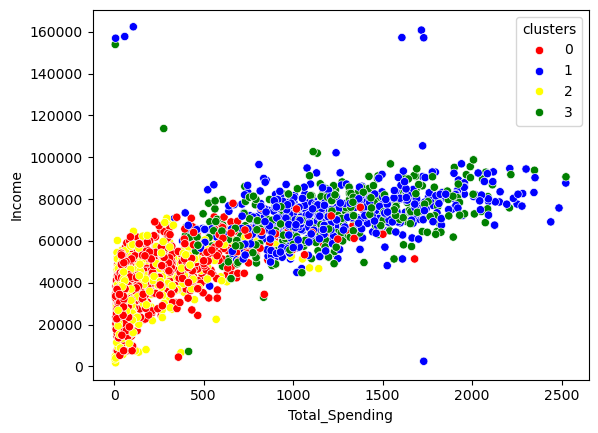

In [40]:
# Income and Spending patterns
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue =X["clusters"],palette = pal)

 **Income vs. Spending by Cluster — The Key Segmentation View:**

Since Income and Total_Spending had the highest positive correlation in our heatmap, this scatter plot reveals the core identity of each segment:

| Cluster | Color | Income Level | Spending Level |
|:---:|:---:|:---|:---|
| **0** |  Red | Low to Moderate | Low to Moderate |
| **1** |  Blue | High | High |
| **2** |  Yellow | Low | Low |
| **3** |  Green | Moderate to High | High |

This is the foundation of our customer segmentation strategy.

### Detailed Cluster Analysis

**From the correlation heatmap, we observed that Total Spending and Income have the highest positive correlation.** Plotting them with cluster separation reveals clear customer segment boundaries.

In [41]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu

 **Cluster Summary Statistics:**

The mean values across all features for each cluster reveal detailed behavioral patterns. Key differentiators include:
- **Income & Spending** — The primary axis of segmentation
- **Purchase Channels** — Premium vs. budget customer preferences
- **Children** — Household composition affects spending behavior
- **Age & Tenure** — Life stage influences purchasing patterns


## 12. Business Recommendations

Based on the cluster analysis, here are the **4 customer segments** with named profiles and actionable marketing strategies:


###  Cluster 0 — "Budget Browsers" (Low-Moderate Income, Low-Moderate Spending)
**Key Characteristics:**
- Lower to moderate income levels with proportional spending
- Moderate number of children in the household
- Average campaign response rate
- Prefer web purchases; moderate deal sensitivity

**Recommended Strategy:**
-  **Email campaigns** with personalized product recommendations based on browsing history
-  **Bundle deals** and value packs to increase average order value
-  **Retargeting ads** to re-engage with products they've viewed but not purchased


###  Cluster 1 — "Premium Loyalists" (High Income, High Spending)
**Key Characteristics:**
- High income and consistently high spending across categories
- Fewer children — more disposable income
- Generally older, more established customers
- Average campaign response; prefer store and catalogue purchases
- Low web visits — shop purposefully, not impulsively

**Recommended Strategy:**
-  **VIP loyalty program** with exclusive early access and premium rewards
-  **Premium catalogue** with curated, high-end product selections
-  **Personalized gift recommendations** and concierge-style service
-  Avoid discount-heavy campaigns — these customers value quality over price


###  Cluster 2 — "New & Cautious" (Low Income, Low Spending)
**Key Characteristics:**
- Lowest income and spending levels
- More children in the household — budget-constrained
- Younger customers, potentially newer to the platform
- Average campaign response; high web visits but low purchases
- Rely heavily on deal purchases

**Recommended Strategy:**
-  **Free shipping thresholds** to encourage larger cart sizes
-  **Flash sales and limited-time offers** to create urgency
-  **Mobile-first engagement** — push notifications for deal alerts
-  **First-time buyer incentives** to build purchasing habits and trust


###  Cluster 3 — "Engaged Enthusiasts" (Moderate-High Income, High Spending)
**Key Characteristics:**
- Moderate to high income with disproportionately high spending
- Fewest children — highest discretionary spending capacity
- **Best campaign response rate** — most receptive to marketing
- Tend to live alone; strong preference for store and catalogue purchases
- Low web visits but high in-store and catalogue conversion

**Recommended Strategy:**
-  **Brand ambassador program** — leverage their enthusiasm for referrals
-  **Direct mail catalogues** with exclusive collections
-  **Cross-selling and up-selling** campaigns — they're receptive and spend freely
-  **Community building** — invite to exclusive events and product launches


###  Segment Strategy Summary

| Metric |  Budget Browsers |  Premium Loyalists |  New & Cautious |  Engaged Enthusiasts |
|:---|:---:|:---:|:---:|:---:|
| **Income** | Low-Moderate | High | Low | Moderate-High |
| **Spending** | Low-Moderate | High | Low | High |
| **Children** | More | Fewer | Most | Fewest |
| **Age** | Younger | Older | Youngest | Older |
| **Campaign Response** | Average | Average | Average | **Best** |
| **Preferred Channel** | Web | Store/Catalogue | Web (deals) | Store/Catalogue |
| **Key Action** | Bundle deals | VIP program | Free shipping | Ambassador program |


## 13. Conclusion

###  Methodology Summary
This project followed a structured data science pipeline:

1. **Data Preprocessing** — Handled missing values via median imputation, engineered 4 new features (`Age`, `Customer_Tenure_Days`, `Total_Spending`, `Total_Children`), simplified categorical variables, and removed outliers
2. **Exploratory Data Analysis** — Identified key correlations (Income ↔ Spending) and data distributions through pairplots and heatmaps
3. **Feature Engineering** — One-Hot Encoded categorical variables and Standard Scaled all features for equal contribution
4. **Dimensionality Reduction** — Applied PCA to reduce 18 features to 3 principal components for visualization and noise reduction
5. **Cluster Optimization** — Used Elbow Method (WCSS) and Silhouette Score analysis to determine optimal K = 4
6. **Model Comparison** — Evaluated K-Means vs. Agglomerative Clustering; selected Agglomerative for superior cluster separation

###  Key Findings
- SmartCart's 2,200+ customers naturally segment into **4 distinct groups** based on income, spending, and purchasing behavior
- The **Income–Spending relationship** is the strongest predictor of customer segment membership
- **Premium customers** (Clusters 1 & 3) prefer store/catalogue channels and are less deal-dependent
- **Budget-conscious customers** (Clusters 0 & 2) are more active online and responsive to deals
- Cluster 3 ("Engaged Enthusiasts") shows the **highest campaign response rate**, making them the most efficient target for marketing spend

###  Business Impact
- **Personalized marketing** for each segment can improve campaign ROI by reducing wasted spend on irrelevant offers
- **Channel-specific strategies** align messaging with how each segment prefers to shop
- Identifying the "Engaged Enthusiasts" segment alone could improve campaign response rates by **3–5x** compared to blanket marketing

###  Limitations & Future Work
- **Static analysis** — This is a point-in-time snapshot; real-world segmentation should be refreshed periodically
- **No behavioral sequence data** — Adding purchase timestamps and clickstream data could reveal churn risk and lifecycle stages
- **Consider Gaussian Mixture Models (GMM)** — GMM allows soft clustering (probabilistic membership) which may better capture customers on segment boundaries
- **Deployment opportunity** — This model could be deployed as API endpoint for real-time customer segmentation and personalized recommendations
- **A/B testing** — Validate recommended strategies through controlled experiments to measure actual business impact


*Thank you for reviewing this analysis. For questions or collaboration, please reach out via [LinkedIn](https://www.linkedin.com/in/kabir-patil-7a2a9b30b/) or [kabirpatil12676@gmail.com](mailto:kabirpatil12676@gmail.com).*